---

<div align="center">
  <img src="https://raw.githubusercontent.com/devicons/devicon/master/icons/python/python-original.svg" width="80"/>
</div>

<h1 align="center">GenAI & Advanced Nets: Classificação de Sentimentos com BiLSTM</h1>

<h3 align="center">PhD. Julles Mitoura</h3>

<div align="center">
  <img src="https://img.shields.io/badge/Python-3776AB?style=for-the-badge&logo=python&logoColor=white"/>
  <img src="https://img.shields.io/badge/Jupyter-F37626?style=for-the-badge&logo=jupyter&logoColor=white"/>
</div>

---

In [ ]:
# Obs: se você não estiver utilizando um ambiente virtual, instale as bibliotecas conforme se apresenta abaixo
# %pip install -q -r requirements.txt

# pip é o gerenciador de pacotes do Python. Pense nele como o instalador oficial de libs Python.
# no notebook, usar %pip ... é ideal porque instala no mesmo ambiente do kernel em uso.

# -q: quiet
# -r: requirement file, indica ao pip para instalar os pacotes listados no arquivo requirements.txt

---

<div align="center">

## <span style="color:#1E90FF;">Modelo BiLSTM</span>

</div>

Neste notebook utilizamos uma rede **BiLSTM** (*Bidirectional Long Short-Term Memory*) para classificar sentimentos em **6 classes**: *anger*, *fear*, *joy*, *love*, *sadness* e *surprise*.

As redes LSTM são um tipo especial de rede neural recorrente (RNN) capaz de aprender dependências de longo prazo em sequências textuais. A variante **bidirecional** processa a sequência de entrada tanto da esquerda para a direita quanto da direita para a esquerda, capturando contexto em ambas as direções e resultando em representações mais ricas para tarefas de classificação de texto.

A arquitetura completa será apresentada em detalhe na etapa de treinamento, incluindo `model.summary()`.

In [1]:
# imports
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import spacy
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score

# fixando a seed para garantir reprodutibilidade
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print('TensorFlow:', tf.__version__)

TensorFlow: 2.19.0


---

<div align="center">

## <span style="color:#1E90FF;">Tratamento de Dados</span>

</div>

Nesta etapa realizamos o pré-processamento dos dados textuais. As principais operações são:

- **Carga dos dados**: leitura dos arquivos de treino e teste;
- **Análise exploratória**: visualização da distribuição das classes para identificar possíveis desbalanceamentos;
- **Pré-processamento com spaCy**: lematização e remoção de stopwords e pontuação;
- **Separação treino/validação**: divisão estratificada para preservar a proporção entre as classes;
- **Codificação dos rótulos**: transformação dos rótulos textuais em identificadores numéricos.

In [2]:
def load_dataset(path: str) -> pd.DataFrame:
    """
    Lê o dataset separado por ';' dividindo sempre pelo ÚLTIMO ponto e vírgula,
    garantindo que textos que contenham ';' sejam lidos corretamente.
    Formato esperado por linha:  texto;sentimento
    """
    records = []
    with open(path, encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            idx = line.rfind(';')
            records.append({'texto': line[:idx], 'sentimento': line[idx + 1:]})
    return pd.DataFrame(records)

train_path = 'dataset/data_train.txt'
test_path  = 'dataset/data_test.txt'

df_train = load_dataset(train_path)
df_test  = load_dataset(test_path)

print('Shape treino:', df_train.shape)
print('Shape teste :', df_test.shape)
print('\nClasses no treino:', sorted(df_train['sentimento'].unique()))
print('Classes no teste :', sorted(df_test['sentimento'].unique()))

display(df_train.head(3))

Shape treino: (16000, 2)
Shape teste : (2000, 2)

Classes no treino: ['anger', 'fear', 'joy', 'love', 'sadness', 'surprise']
Classes no teste : ['anger', 'fear', 'joy', 'love', 'sadness', 'surprise']


,texto,sentimento
0,i am feeling completely overwhelmed i have two...,fear
1,i have the feeling she was amused and delighted,joy
2,i was able to help chai lifeline with your sup...,joy


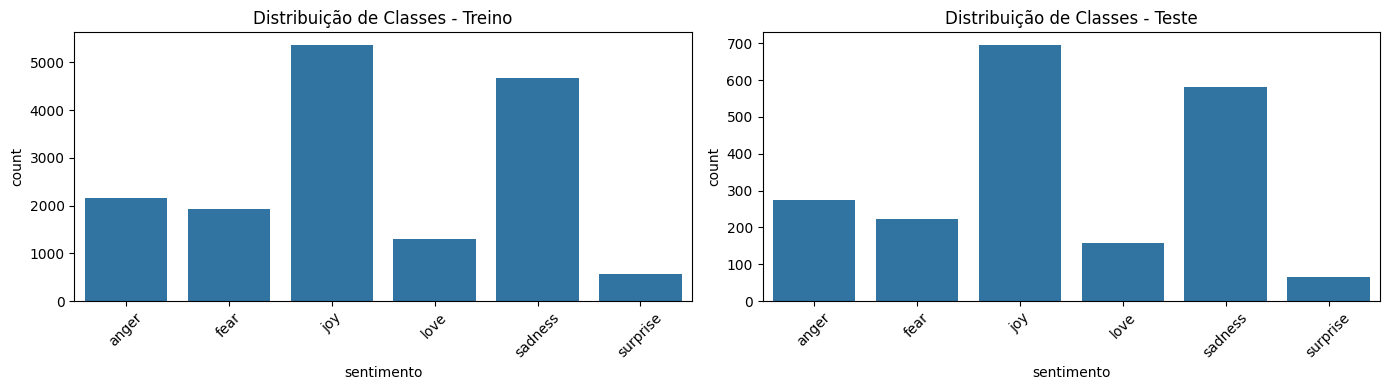

In [3]:
# distribuição das classes nos conjuntos de treino e teste
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.countplot(data=df_train, x='sentimento', order=sorted(df_train['sentimento'].unique()), ax=axes[0])
axes[0].set_title('Distribuição de Classes - Treino')
axes[0].tick_params(axis='x', rotation=45)

sns.countplot(data=df_test, x='sentimento', order=sorted(df_test['sentimento'].unique()), ax=axes[1])
axes[1].set_title('Distribuição de Classes - Teste')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [4]:
try:
    nlp = spacy.load('en_core_web_sm')
except OSError:
    import subprocess
    subprocess.run(['python', '-m', 'spacy', 'download', 'en_core_web_sm'], check=True)
    nlp = spacy.load('en_core_web_sm')


def spacy_preprocess_text(texto: str) -> str:
    doc = nlp(str(texto))
    tokens = [
        tok.lemma_.lower().strip()
        for tok in doc
        if (not tok.is_stop) and (not tok.is_punct) and (not tok.is_space)
    ]
    return ' '.join([t for t in tokens if t])


df_train_spa = df_train.copy()
df_test_spa = df_test.copy()

df_train_spa['texto_processado'] = df_train_spa['texto'].apply(spacy_preprocess_text)
df_test_spa['texto_processado'] = df_test_spa['texto'].apply(spacy_preprocess_text)

display(df_train_spa[['texto', 'texto_processado', 'sentimento']].head(3))

,texto,texto_processado,sentimento
0,i am feeling completely overwhelmed i have two...,feel completely overwhelmed strategy help feel...,fear
1,i have the feeling she was amused and delighted,feeling amuse delight,joy
2,i was able to help chai lifeline with your sup...,able help chai lifeline support encouragement ...,joy


In [6]:
df_train_spa_inner, df_valid_spa = train_test_split(
    df_train_spa,
    test_size=0.2,
    random_state=SEED,
    stratify=df_train_spa['sentimento'],
)

le_global = LabelEncoder()
le_global.fit(df_train_spa['sentimento'])

X_train_txt = df_train_spa_inner['texto_processado'].tolist()
X_valid_txt = df_valid_spa['texto_processado'].tolist()
X_test_txt = df_test_spa['texto_processado'].tolist()

y_train_id = le_global.transform(df_train_spa_inner['sentimento'])
y_valid_id = le_global.transform(df_valid_spa['sentimento'])
y_test_id = le_global.transform(df_test_spa['sentimento'])

class_names = list(le_global.classes_)
num_classes = len(class_names)

classes_ids = np.unique(y_train_id)
weights = compute_class_weight(class_weight='balanced', classes=classes_ids, y=y_train_id)
class_weights_common = {int(c): float(w) for c, w in zip(classes_ids, weights)}

print('Classes:', class_names)
print('Treino:', len(X_train_txt), '| Validacao:', len(X_valid_txt), '| Teste:', len(X_test_txt))

Classes: ['anger', 'fear', 'joy', 'love', 'sadness', 'surprise']
Treino: 12800 | Validacao: 3200 | Teste: 2000


---

<div align="center">

## <span style="color:#1E90FF;">Treinamento do Modelo</span>

</div>

Esta etapa cobre três fases encadeadas:

**1. Preparação das sequências** — os textos pré-processados são convertidos em sequências de índices inteiros pelo `Tokenizer` e padronizados para o mesmo comprimento com `pad_sequences`. Isso transforma o texto em tensores que a rede consegue processar.

**2. Definição da arquitetura** — a rede BiLSTM é composta pelas seguintes camadas:

| Camada | Descrição |
|--------|-----------|
| `Embedding` | Mapeia cada índice de token em um vetor denso de `EMBED_DIM` dimensões, aprendido durante o treino |
| `Bidirectional(LSTM)` | Processa a sequência da esquerda para a direita **e** da direita para a esquerda, capturando contexto bidirecional |
| `Dropout` | Desliga aleatoriamente neurônios durante o treino para reduzir overfitting |
| `Dense(relu)` | Camada intermediária de representação não-linear |
| `Dense(softmax)` | Camada de saída que projeta para as `num_classes` classes com probabilidades |

**3. Treinamento** — utiliza o otimizador **Adam** com `sparse_categorical_crossentropy` como função de perda. O callback `EarlyStopping` monitora a `val_loss` e interrompe o treino caso não haja melhora por `patience=4` épocas consecutivas, restaurando automaticamente os pesos da melhor época.

In [7]:
# ── Preparação das sequências ─────────────────────────────────────────────────

# hiperparâmetros do modelo
EPOCHS = 12
BATCH = 64
MAX_WORDS = 30000
MAX_LEN = 100
EMBED_DIM = 128

# tokenização: converte cada token em um índice inteiro único
tok_lstm = Tokenizer(num_words=MAX_WORDS, oov_token='<OOV>')
tok_lstm.fit_on_texts(X_train_txt)

seq_train = tok_lstm.texts_to_sequences(X_train_txt)
seq_valid = tok_lstm.texts_to_sequences(X_valid_txt)
seq_test = tok_lstm.texts_to_sequences(X_test_txt)

# padding: garante que todas as sequências tenham o mesmo comprimento (MAX_LEN)
X_train_lstm = pad_sequences(seq_train, maxlen=MAX_LEN, padding='post', truncating='post')
X_valid_lstm = pad_sequences(seq_valid, maxlen=MAX_LEN, padding='post', truncating='post')
X_test_lstm = pad_sequences(seq_test, maxlen=MAX_LEN, padding='post', truncating='post')

vocab_size_lstm = min(MAX_WORDS, len(tok_lstm.word_index) + 1)

print(f'Vocabulário: {vocab_size_lstm} tokens')
print(f'Shape treino  : {X_train_lstm.shape}')
print(f'Shape validação: {X_valid_lstm.shape}')
print(f'Shape teste   : {X_test_lstm.shape}')

# ── Arquitetura ───────────────────────────────────────────────────────────────

model_lstm = Sequential([
    Embedding(input_dim=vocab_size_lstm, output_dim=EMBED_DIM, input_length=MAX_LEN),
    Bidirectional(LSTM(64)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(num_classes, activation='softmax'),
])

model_lstm.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)

print('\nResumo da arquitetura BiLSTM:')
model_lstm.summary()

# ── Treinamento ───────────────────────────────────────────────────────────────

# EarlyStopping: interrompe o treino quando val_loss não melhora por patience épocas
early_lstm = EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True)

history_lstm = model_lstm.fit(
    X_train_lstm,
    y_train_id,
    validation_data=(X_valid_lstm, y_valid_id),
    epochs=EPOCHS,
    batch_size=BATCH,
    class_weight=class_weights_common,
    callbacks=[early_lstm],
    verbose=1,
)

Vocabulário: 10584 tokens
Shape treino  : (12800, 100)
Shape validação: (3200, 100)
Shape teste   : (2000, 100)

Resumo da arquitetura BiLSTM:


/Users/mitoura/Desktop/FIAP/Materiais/GenerativeAI/.venv/lib/python3.11/site-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/12
200/200 ━━━━━━━━━━━━━━━━━━━━ 15s 69ms/step - accuracy: 0.3676 - loss: 1.5067 - val_accuracy: 0.7491 - val_loss: 0.7825
Epoch 2/12
200/200 ━━━━━━━━━━━━━━━━━━━━ 16s 81ms/step - accuracy: 0.8505 - loss: 0.4371 - val_accuracy: 0.8594 - val_loss: 0.4279
Epoch 3/12
200/200 ━━━━━━━━━━━━━━━━━━━━ 18s 90ms/step - accuracy: 0.9348 - loss: 0.1869 - val_accuracy: 0.8600 - val_loss: 0.4392
Epoch 4/12
200/200 ━━━━━━━━━━━━━━━━━━━━ 17s 84ms/step - accuracy: 0.9620 - loss: 0.1078 - val_accuracy: 0.8606 - val_loss: 0.4855
Epoch 5/12
200/200 ━━━━━━━━━━━━━━━━━━━━ 17s 87ms/step - accuracy: 0.9713 - loss: 0.0745 - val_accuracy: 0.8653 - val_loss: 0.5359
Epoch 6/12
200/200 ━━━━━━━━━━━━━━━━━━━━ 18s 92ms/step - accuracy: 0.9767 - loss: 0.0684 - val_accuracy: 0.8662 - val_loss: 0.5787


---

<div align="center">

## <span style="color:#1E90FF;">Avaliação do Modelo</span>

</div>

Com o modelo treinado, avaliamos seu desempenho no conjunto de teste, que não foi visto durante o treinamento. As métricas utilizadas são:

- **Loss e Acurácia**: métricas globais calculadas diretamente pelo Keras no conjunto de teste;
- **Acurácia geral**: proporção de amostras classificadas corretamente;
- **F1-Score Macro**: média do F1 por classe, sem ponderação — penaliza mais o desempenho ruim em classes menores;
- **F1-Score Weighted**: média do F1 ponderada pelo suporte de cada classe;
- **Relatório de classificação**: precisão, recall e F1 detalhados por classe;
- **Curvas de aprendizado**: evolução do *loss* e da acurácia ao longo das épocas de treino e validação;
- **Matriz de confusão**: visualização dos erros de predição entre classes.

=== Resultado: BiLSTM ===
Test loss         : 0.4096
Test accuracy     : 0.8635
Accuracy geral    : 0.8635
F1 Macro          : 0.8162
F1 Weighted       : 0.8665

              precision    recall  f1-score   support

       anger       0.85      0.84      0.84       275
        fear       0.84      0.83      0.84       224
         joy       0.95      0.86      0.90       695
        love       0.66      0.82      0.74       159
     sadness       0.89      0.91      0.90       581
    surprise       0.58      0.80      0.68        66

    accuracy                           0.86      2000
   macro avg       0.80      0.84      0.82      2000
weighted avg       0.87      0.86      0.87      2000



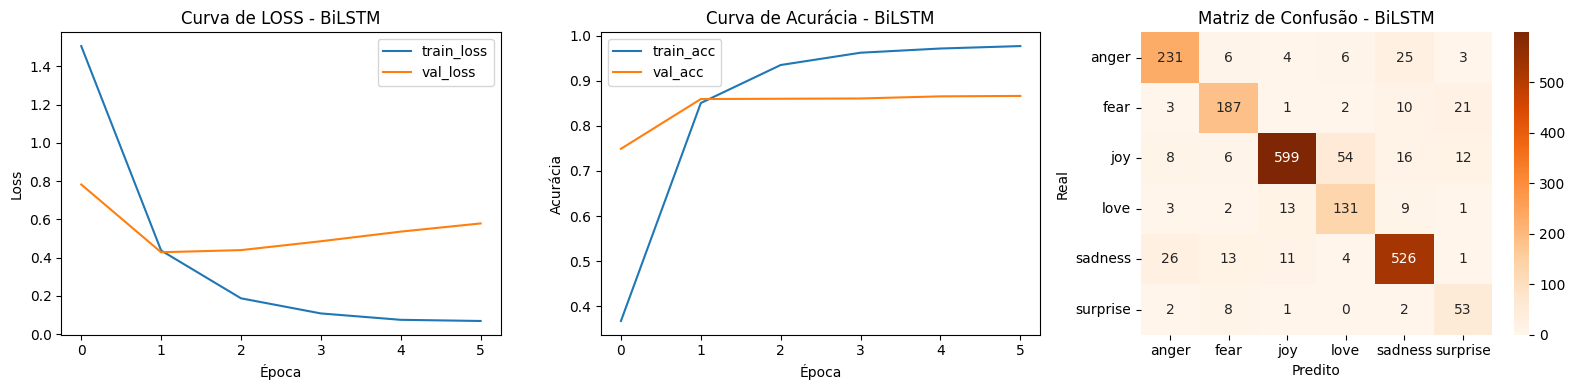

In [8]:
# avaliação do modelo no conjunto de teste
test_loss_lstm, test_acc_lstm = model_lstm.evaluate(X_test_lstm, y_test_id, verbose=0)
pred_lstm = np.argmax(model_lstm.predict(X_test_lstm, verbose=0), axis=1)

y_true_lbl = le_global.inverse_transform(y_test_id)
y_pred_lstm_lbl = le_global.inverse_transform(pred_lstm)

lstm_acc = accuracy_score(y_true_lbl, y_pred_lstm_lbl)
lstm_f1_macro = f1_score(y_true_lbl, y_pred_lstm_lbl, average='macro')
lstm_f1_weighted = f1_score(y_true_lbl, y_pred_lstm_lbl, average='weighted')

# métricas gerais
print('=== Resultado: BiLSTM ===')
print(f'Test loss         : {test_loss_lstm:.4f}')
print(f'Test accuracy     : {test_acc_lstm:.4f}')
print(f'Accuracy geral    : {lstm_acc:.4f}')
print(f'F1 Macro          : {lstm_f1_macro:.4f}')
print(f'F1 Weighted       : {lstm_f1_weighted:.4f}\n')
print(classification_report(y_true_lbl, y_pred_lstm_lbl, zero_division=0))

# curvas de aprendizado
plt.figure(figsize=(16, 4))
plt.subplot(1, 3, 1)
plt.plot(history_lstm.history['loss'], label='train_loss')
plt.plot(history_lstm.history['val_loss'], label='val_loss')
plt.title('Curva de LOSS - BiLSTM')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(history_lstm.history['accuracy'], label='train_acc')
plt.plot(history_lstm.history['val_accuracy'], label='val_acc')
plt.title('Curva de Acurácia - BiLSTM')
plt.xlabel('Época')
plt.ylabel('Acurácia')
plt.legend()
plt.tight_layout()

# matriz de confusão
cm_lstm = confusion_matrix(y_true_lbl, y_pred_lstm_lbl, labels=class_names)
plt.subplot(1, 3, 3)
sns.heatmap(cm_lstm, annot=True, fmt='d', cmap='Oranges', xticklabels=class_names, yticklabels=class_names)
plt.title('Matriz de Confusão - BiLSTM')
plt.xlabel('Predito')
plt.ylabel('Real')
plt.tight_layout()
plt.show()

---

<div align="center">

## <span style="color:#1E90FF;">Avaliação com Frases Externas</span>

</div>

Para verificar a capacidade de **generalização** do modelo, aplicamos o BiLSTM a três frases que estão completamente **fora do escopo dos dados de treino**. O objetivo é observar como o modelo interpreta texto novo e quais classes ele atribui — incluindo os casos em que a predição pode divergir da intuição humana.

=== Predições: BiLSTM ===

Frase 1: "Today I got my dream job offer after months of waiting. I can barely breathe. I am ralley happy."
  → Classe predita : SADNESS  (confiança: 39.9%)
  → Texto processado: "today get dream job offer month wait barely breathe ralley happy"

Frase 2: "My dog passed away this morning. The house feels empty without him."
  → Classe predita : SADNESS  (confiança: 43.0%)
  → Texto processado: "dog pass away morning house feel"

Frase 3: "They raised the price of my coffee again. Three times in one year!"
  → Classe predita : JOY  (confiança: 51.1%)
  → Texto processado: "raise price coffee time year"



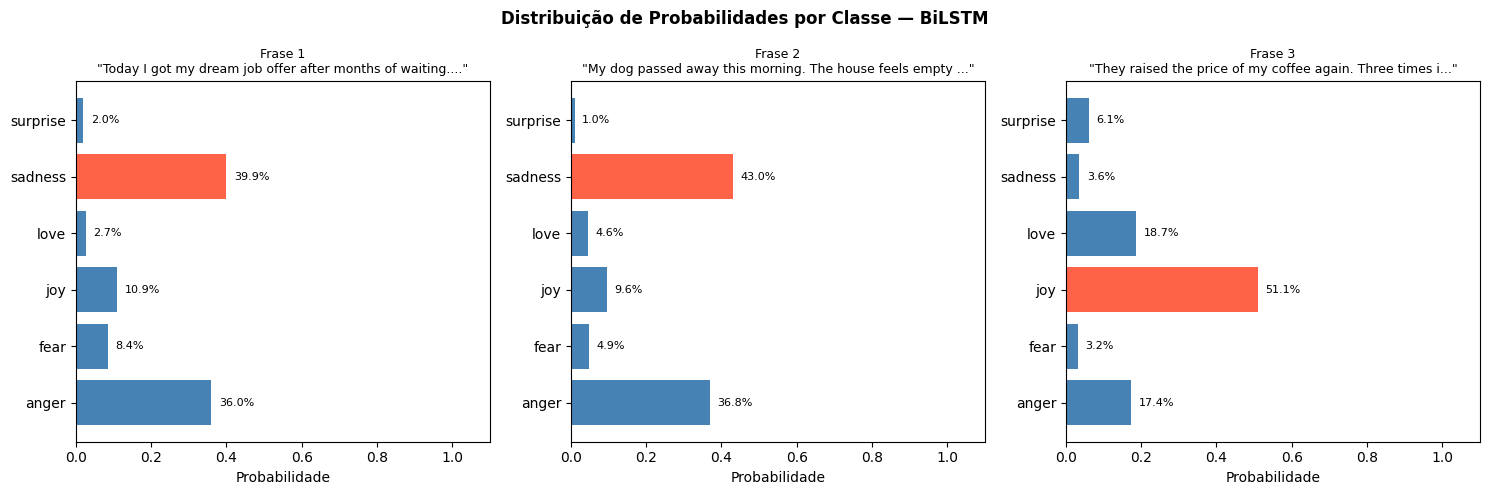

In [9]:
# frases externas — fora do escopo dos dados de treino
frases_externas = [
    "Today I got my dream job offer after months of waiting. I can barely breathe. I am ralley happy.",
    "My dog passed away this morning. The house feels empty without him.",
    "They raised the price of my coffee again. Three times in one year!",
]

# pré-processamento com spaCy (mesmo pipeline usado no treino)
frases_processadas = [spacy_preprocess_text(f) for f in frases_externas]

# tokenização e padding com o vocabulário ajustado no treino
seqs_ext = tok_lstm.texts_to_sequences(frases_processadas)
X_ext    = pad_sequences(seqs_ext, maxlen=MAX_LEN, padding='post', truncating='post')

# predição: probabilidades por classe
probs_ext = model_lstm.predict(X_ext, verbose=0)
preds_ext = probs_ext.argmax(axis=-1)
labels_ext = le_global.inverse_transform(preds_ext)

# resultados textuais
print('=== Predições: BiLSTM ===\n')
for i, (frase, label, prob) in enumerate(zip(frases_externas, labels_ext, probs_ext)):
    print(f'Frase {i + 1}: "{frase}"')
    print(f'  → Classe predita : {label.upper()}  (confiança: {prob.max():.1%})')
    print(f'  → Texto processado: "{frases_processadas[i]}"\n')

# visualização: distribuição de probabilidades por classe
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, (frase, prob, pred) in enumerate(zip(frases_externas, probs_ext, labels_ext)):
    cores = ['tomato' if c == pred else 'steelblue' for c in class_names]
    bars  = axes[i].barh(class_names, prob, color=cores)
    titulo = f'Frase {i + 1}\n"{frase[:55]}..."' if len(frase) > 55 else f'Frase {i + 1}\n"{frase}"'
    axes[i].set_title(titulo, fontsize=9)
    axes[i].set_xlim(0, 1.1)
    axes[i].set_xlabel('Probabilidade')
    for bar, p in zip(bars, prob):
        axes[i].text(bar.get_width() + 0.02, bar.get_y() + bar.get_height() / 2,
                     f'{p:.1%}', va='center', fontsize=8)

plt.suptitle('Distribuição de Probabilidades por Classe — BiLSTM', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

---

<div align="center">

## <span style="color:#1E90FF;">Salvamento do Modelo</span>

</div>

Para reutilizar o modelo em produção ou em notebooks futuros, é necessário salvar **todos os artefatos do pipeline de inferência** — não apenas os pesos da rede. Para o BiLSTM, três arquivos são necessários:

| Arquivo | Conteúdo | Usado para |
|---------|----------|------------|
| `bilstm_sentiment.keras` | Pesos e arquitetura do modelo | Predição |
| `bilstm_tokenizer.pkl` | Vocabulário e índices do `Tokenizer` | Converter texto → sequência de inteiros |
| `bilstm_label_encoder.pkl` | Mapeamento id ↔ rótulo | Converter id numérico → nome da classe |

Para recarregar e usar o modelo:

```python
import pickle
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.sequence import pad_sequences

model  = load_model('models/bilstm_sentiment.keras')
tok    = pickle.load(open('models/bilstm_tokenizer.pkl', 'rb'))
le     = pickle.load(open('models/bilstm_label_encoder.pkl', 'rb'))

texto = ["I feel so happy today!"]
seq   = tok.texts_to_sequences(texto)
X     = pad_sequences(seq, maxlen=100, padding='post', truncating='post')
pred  = le.inverse_transform(model.predict(X).argmax(axis=-1))
print(pred)
```

In [10]:
import pickle
import os

os.makedirs('models', exist_ok=True)

# salva os pesos e a arquitetura do modelo BiLSTM no formato nativo do Keras
model_lstm.save('models/bilstm_sentiment.keras')

# salva o Tokenizer (vocabulário e índices) necessário para converter novos textos
with open('models/bilstm_tokenizer.pkl', 'wb') as f:
    pickle.dump(tok_lstm, f)

# salva o LabelEncoder (mapeamento id ↔ rótulo) necessário para interpretar as predições
with open('models/bilstm_label_encoder.pkl', 'wb') as f:
    pickle.dump(le_global, f)

print('Artefatos salvos em models/:')
for fname in ['bilstm_sentiment.keras', 'bilstm_tokenizer.pkl', 'bilstm_label_encoder.pkl']:
    path = f'models/{fname}'
    size = os.path.getsize(path) / 1024
    print(f'  {fname:35s}  {size:7.1f} KB')

Artefatos salvos em models/:
  bilstm_sentiment.keras               17182.3 KB
  bilstm_tokenizer.pkl                   409.3 KB
  bilstm_label_encoder.pkl                 0.3 KB
